#### 2026년 6월 날씨 영향 회귀 모델

- `data/OBS_ASOS_TIM_20260814151604.csv` — 기상청 서울(108) 지점, 2026.06.01~06.30 시간별 기온/강수량/풍속/습도
- `data/서울특별시_공공자전거_이용정보_시간대별__202606.csv` — 같은 기간 서울시 전체 대여 이용 로그 (02번 노트북에서 쓴 것과 동일 원본, 여기선 서울시 전체 합계로만 다시 집계해서 사용)

##### 왜 이번엔 두 파일을 같이 봐야 하나요?

01·02번 노트북은 "합치지 말라"고 하신 대로 파일 하나씩만 썼어요. 근데 "날씨가 대여량에 미치는 영향"을 학습하려면, 애초에 '이 시각의 날씨'와 '이 시각의 대여량'을 짝지어야만 학습이 가능해요 (그래야 "비가 오면 대여가 준다"는 관계를 모델이 배울 수 있어요). 이건 이전에 말씀하신 "서로 안 맞는 데이터를 억지로 하나로 합쳐서 새 데이터셋 만들기"와는 다릅니다 — 같은 기간(2026년 6월)·같은 시간 단위로 원래 붙어 있어야 할 정보를 짝짓는 것뿐이고, 두 파일을 새로운 파일로 저장하지도 않습니다 (노트북 안에서만 임시로 merge).


#### 1. 라이브러리 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

pd.set_option('display.max_columns', None)

#### 2. 데이터 불러오기 - 기상청 6월 날씨 데이터

In [3]:
weather = pd.read_csv('../data/OBS_ASOS_TIM_20260814151604.csv', encoding='cp949')
weather.columns = ['station_code','station_name','datetime','temperature','rainfall','wind_speed','humidity']
weather['datetime'] = pd.to_datetime(weather['datetime'])
weather['rainfall'] = weather['rainfall'].fillna(0)  # 강수량 결측 = 비 안 옴
weather.head()

,station_code,station_name,datetime,temperature,rainfall,wind_speed,humidity
0,108,서울,2026-06-01 00:00:00,21.1,0.0,0.8,43
1,108,서울,2026-06-01 01:00:00,20.3,0.0,0.9,45
2,108,서울,2026-06-01 02:00:00,19.9,0.0,1.1,46
3,108,서울,2026-06-01 03:00:00,19.5,0.0,1.4,47
4,108,서울,2026-06-01 04:00:00,18.7,0.0,1.3,51


In [4]:
print('행/열:', weather.shape)
weather.isnull().sum()

행/열: (720, 7)


station_code    0
station_name    0
datetime        0
temperature     0
rainfall        0
wind_speed      0
humidity        0
dtype: int64

#### 3. 데이터 불러오기 대여 이용 로그 → 서울시 전체 시간별 합계로 집계

In [6]:
usage = pd.read_csv(
    '../data/서울특별시 공공자전거 이용정보(시간대별)_202606.csv',
    encoding='cp949'
)
# 대여소 구분 없이, 날짜+시간별로 서울시 전체 합산
city_hourly = usage.groupby(['대여일자','대여시간'], as_index=False)['이용건수'].sum()
city_hourly.columns = ['date','hour','total_rentals']
city_hourly['datetime'] = pd.to_datetime(city_hourly['date']) + pd.to_timedelta(city_hourly['hour'], unit='h')
city_hourly.head()

,date,hour,total_rentals,datetime
0,2026-06-01,0,2378,2026-06-01 00:00:00
1,2026-06-01,1,1477,2026-06-01 01:00:00
2,2026-06-01,2,992,2026-06-01 02:00:00
3,2026-06-01,3,699,2026-06-01 03:00:00
4,2026-06-01,4,716,2026-06-01 04:00:00


#### 4. 두 데이터 짝짓기 (같은 시각끼리 merge)

In [7]:
merged = pd.merge(weather, city_hourly, on='datetime', how='inner')
print('짝지어진 행 수:', len(merged))
merged.head()

짝지어진 행 수: 720


,station_code,station_name,datetime,temperature,rainfall,wind_speed,humidity,date,hour,total_rentals
0,108,서울,2026-06-01 00:00:00,21.1,0.0,0.8,43,2026-06-01,0,2378
1,108,서울,2026-06-01 01:00:00,20.3,0.0,0.9,45,2026-06-01,1,1477
2,108,서울,2026-06-01 02:00:00,19.9,0.0,1.1,46,2026-06-01,2,992
3,108,서울,2026-06-01 03:00:00,19.5,0.0,1.4,47,2026-06-01,3,699
4,108,서울,2026-06-01 04:00:00,18.7,0.0,1.3,51,2026-06-01,4,716


#### 5. EDA

In [8]:
merged[['temperature','rainfall','wind_speed','humidity','total_rentals']].describe()

,temperature,rainfall,wind_speed,humidity,total_rentals
count,720.00000,720.000000,720.000000,720.000000,720.000000
mean,24.02500,0.119444,2.145139,60.411111,5647.754167
std,3.90962,0.992803,0.921391,14.936412,3851.383505
min,15.70000,0.000000,0.000000,29.000000,59.000000
25%,21.20000,0.000000,1.500000,49.000000,2462.000000
50%,23.60000,0.000000,2.100000,60.000000,5041.500000
75%,26.80000,0.000000,2.700000,71.000000,7992.500000
max,33.30000,15.300000,5.200000,97.000000,17688.000000


/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/

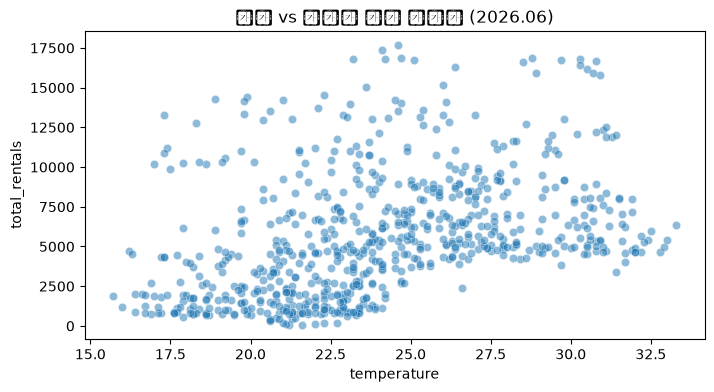

In [9]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=merged, x='temperature', y='total_rentals', alpha=0.5)
plt.title('기온 vs 서울시 전체 대여량 (2026.06)')
plt.show()

/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon

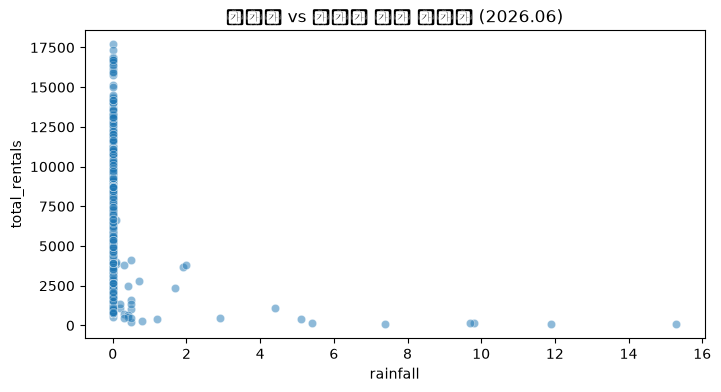

In [10]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=merged, x='rainfall', y='total_rentals', alpha=0.5)
plt.title('강수량 vs 서울시 전체 대여량 (2026.06)')
plt.show()

#### 6. 피처 만들기 (시간/요일)

In [11]:
merged['hour'] = merged['datetime'].dt.hour
merged['day_of_week'] = merged['datetime'].dt.dayofweek
merged['is_weekend'] = (merged['day_of_week'] >= 5).astype(int)
merged.head()

,station_code,station_name,datetime,temperature,rainfall,wind_speed,humidity,date,hour,total_rentals,day_of_week,is_weekend
0,108,서울,2026-06-01 00:00:00,21.1,0.0,0.8,43,2026-06-01,0,2378,0,0
1,108,서울,2026-06-01 01:00:00,20.3,0.0,0.9,45,2026-06-01,1,1477,0,0
2,108,서울,2026-06-01 02:00:00,19.9,0.0,1.1,46,2026-06-01,2,992,0,0
3,108,서울,2026-06-01 03:00:00,19.5,0.0,1.4,47,2026-06-01,3,699,0,0
4,108,서울,2026-06-01 04:00:00,18.7,0.0,1.3,51,2026-06-01,4,716,0,0


#### 7. 학습/검증 데이터 분리

In [12]:
features = ['hour','day_of_week','is_weekend','temperature','rainfall','wind_speed','humidity']
X = merged[features]
y = merged['total_rentals']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(576, 7) (144, 7)


#### 8. RandomForest 회귀 모델 학습

In [13]:
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

#### 9. 모델 평가

In [14]:
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
print(f'MAE: {mae:.2f}')
print(f'R2 Score: {r2:.4f}')

MAE: 637.50
R2 Score: 0.8987


/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/de

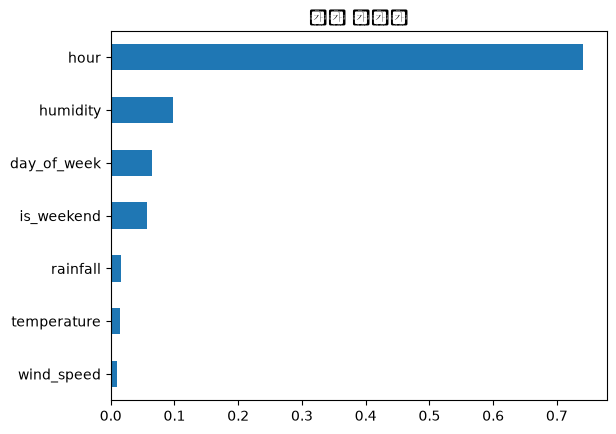

In [15]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
importance.plot(kind='barh')
plt.title('피처 중요도')
plt.gca().invert_yaxis()
plt.show()

#### 10. 참고용 기준값 저장 (시간대+평일/주말별 평균)
FastAPI에서 '이 조건이 평소보다 수요를 얼마나 늘리는지' 배수를 계산할 때 쓸 기준값입니다.

In [16]:
reference = merged.groupby(['hour','is_weekend'])['total_rentals'].mean().reset_index()
reference.head()

,hour,is_weekend,total_rentals
0,0,0,2580.636364
1,0,1,3287.000000
2,1,0,1710.818182
3,1,1,2277.125000
4,2,0,1135.227273


#### 11. 모델 저장

In [17]:
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/weather_effect_model_202606.pkl')
reference.to_csv('../models/weather_reference_202606.csv', index=False)
print('저장 완료')

저장 완료
